## All About the dataSet (Data Card)
This is orginal data from the Olist, the largest department store which helps us look at the product from different dimensions. After a customer purchases the product from Olist Store a seller gets notified to fulfill that order. Once the customer receives the product, or the estimated delivery date is due, the customer gets a satisfaction survey by email where he can give a note for the purchase experience and write down some comments.

Things to keep in mind about the data
1. An order might have multiple items.
2. Each item might be fulfilled by a distinct seller.


## Problem Statement (Hypothetical)
We need to act as the junior data scientist in Olist and the CEO is unhappy because every department provides conflicting numbers.
1. The Sales team says revenue is growing.
2. The Marketing team says customer acquisition costs are increasing.
3. The Finance team says profit margins are shrinking.
The CEO has hired our team to create a single source of truth. We are responsible for performing a complete EDA and generating business insights.

## Plan Of Action/Approach (High-Level)
After seeing the data, the tables we have got, we can club those tables into one preprocess together, calculate some columns from other if needed, and at last we can see the trends in the data for different columns like revenue, campaign costs and profit margins which are the major concerns along with others




## Step 1: Understanding the data we have
1. Identifyibg all available tables and their relationships
2. Understanding the meaning of each column
3. Determine the primary and foreign keys
4. Review business objectives and metrics.

In [363]:
# 1.1 Load datasests
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

customers = pd.read_csv("../data/input/olist_customers_dataset.csv")
orders = pd.read_csv("../data/input/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/input/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/input/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/input/olist_order_reviews_dataset.csv")
products = pd.read_csv("../data/input/olist_products_dataset.csv")
sellers = pd.read_csv("../data/input/olist_sellers_dataset.csv")
geolocation = pd.read_csv("../data/input/olist_geolocation_dataset.csv")
translation = pd.read_csv("../data/input/product_category_name_translation.csv")

In [364]:
# 1.2 Inventory of datasets

datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "translation": translation
}

inventory = []

for name, df in datasets.items():
    inventory.append(
        {
            "Table": name,
            "Rows": df.shape[0],
            "Columns": df.shape[1]
        }
    )

inventory_df = pd.DataFrame(inventory)
inventory_df

,Table,Rows,Columns
0,customers,99441,5
1,orders,99441,8
2,order_items,112650,7
3,payments,103886,5
4,reviews,99224,7
5,products,32951,9
6,sellers,3095,4
7,geolocation,1000163,5
8,translation,71,2


#### Observations from the inventory
1. Geolocation was expected to have the most number of rows as it contains postal code level information of every area
2. Products and sellers have relatively less number of rows as a demonstration of the fact that sellers and products are less than the number of customer & orders.
3. Reviews also hold a significant amount of rows comparable to orders

In [365]:
# Columns Overview

for name, df in datasets.items():
    print(name.upper())
    print(df.columns.tolist())
    print("-" * 50)

CUSTOMERS
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
--------------------------------------------------
ORDERS
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
--------------------------------------------------
ORDER_ITEMS
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
--------------------------------------------------
PAYMENTS
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
--------------------------------------------------
REVIEWS
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
--------------------------------------------------
PRODUCTS
['product_id', 'product_category_name', 'product_name_len

#### Data Dictionary


In [366]:
# 1.4 Data types

for name, df in datasets.items():
    print(name.upper())
    print(df.dtypes)
    print("\n")


CUSTOMERS
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object


ORDERS
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object


ORDER_ITEMS
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object


PAYMENTS
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object


REVIEWS
review_id                    str
order_id      

#### Observations from data types of columns
1. Most timestamps are currently have a type of string which we may need to convert later on
2. Numerical columns appear to have correct data types based on initial inspection using dtypes.
3. Some categorical columns have numerical data types 

In [367]:
# 1.5 Sample data inspection
for name, df in datasets.items():
    print(name.upper())
    display(df.head())
    print("-" * 50)

CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


--------------------------------------------------
ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


--------------------------------------------------
ORDER_ITEMS


...

--------------------------------------------------
GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


--------------------------------------------------
TRANSLATION


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


--------------------------------------------------


In [368]:
tables = {
    "ORDERS": (orders, ["order_id", "customer_id"]),
    "ORDER_ITEMS": (order_items, ["order_id", "order_item_id"]),
    "PAYMENTS": (payments, ["order_id"]),
    "CUSTOMERS": (customers, ["customer_id", "customer_unique_id"]),
    "PRODUCTS": (products, ["product_id"]),
    "SELLERS": (sellers, ["seller_id"]),
    "REVIEWS": (reviews, ["review_id"])
}

for table_name, (df, cols) in tables.items():
    print(f"\nTable: {table_name}")
    for col in cols:
        print(f"Primary Key Check: {col}")
        print(df[col].nunique(), len(df))


Table: ORDERS
Primary Key Check: order_id
99441 99441
Primary Key Check: customer_id
99441 99441

Table: ORDER_ITEMS
Primary Key Check: order_id
98666 112650
Primary Key Check: order_item_id
21 112650

Table: PAYMENTS
Primary Key Check: order_id
99440 103886

Table: CUSTOMERS
Primary Key Check: customer_id
99441 99441
Primary Key Check: customer_unique_id
96096 99441

Table: PRODUCTS
Primary Key Check: product_id
32951 32951

Table: SELLERS
Primary Key Check: seller_id
3095 3095

Table: REVIEWS
Primary Key Check: review_id
98410 99224


#### Observations per table after sample data inspection
1. Customers Table
- customer_id is unique where as customer_unique_id is repeaeted which means a real customer will have diff customer id for diff order ids and we can confirm this as customer ids are also unique in the orders table along with order ids
- Most of the columns have intuitive clean names, whereas customer id tells the id during placing an order, customer unique id tells the real customer's id
- Primary Key is customer_id

2. Orders Table
- Order id is unique per record and rest columns are self explanatory
- Allows full order lifecycle tracking
- Primary key is order_id

3. Order Items Table
- order_id repeats because one order can contain multiple products
- order_item_id represents the sequence of items within the same order
- Each row represents one product within an order (item-level granularity)
- Primary Key (composite): (order_id, order_item_id)

4. Order Payments Table
- order_id repeats because a single order can have multiple payment installments or methods
- Contains payment-related details such as type, installments, and value
- One order can map to multiple payment records
- Primary Key (composite): (order_id, payment_sequential)

5. Order Reviews Table
- review_id is expected to represent a unique review but shows duplication across order_id in this dataset
- Same review content and timestamps may appear multiple times across different orders
- Suggests data duplication or non-strict review mapping per order
- Primary Key (expected): review_id (but requires validation due to duplicates)

6. Products Table
- product_id is unique for each product
- Contains product category, dimensions, and attributes useful for product analysis
- Some columns may require handling of missing values or encoding for categorical analysis
- Primary Key: product_id

7. Sellers Table
- seller_id is unique for each seller in the marketplace
- Contains seller location information (city, state) useful for geographic analysis
- Clean structure with one row per seller
- Primary Key: seller_id


#### 1.6 Relationship Map and Business Objective

1. customers.customer_id → orders.customer_id
2. orders.order_id → order_items.order_id
3. orders.order_id → payments.order_id
4. orders.order_id → reviews.order_id
5. order_items.product_id → products.product_id
6. order_items.seller_id → sellers.seller_id


### Step 1: Summary
1. Total Tables: 9
2. Primary Keys Identified
3. Relationships Identified
4. Data Types Reviewed


## Step 2: Data Quality Assessement

In this step, we check:
- Missing values
- Duplicates
- Data types issues
- Invalid / inconsistent values
- Data completeness

In [369]:
# 2.1 Missing Values Check
for name, df in datasets.items():
    print("\n", name.upper())
    print(df.isnull().sum().sort_values(ascending=False) / len(df) * 100) # isnull includes all missing values (NaN, None, etc.)


 CUSTOMERS
customer_id                 0.0
customer_unique_id          0.0
customer_zip_code_prefix    0.0
customer_city               0.0
customer_state              0.0
dtype: float64

 ORDERS
order_delivered_customer_date    2.981668
order_delivered_carrier_date     1.793023
order_approved_at                0.160899
order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_estimated_delivery_date    0.000000
dtype: float64

 ORDER_ITEMS
order_id               0.0
order_item_id          0.0
product_id             0.0
seller_id              0.0
shipping_limit_date    0.0
price                  0.0
freight_value          0.0
dtype: float64

 PAYMENTS
order_id                0.0
payment_sequential      0.0
payment_type            0.0
payment_installments    0.0
payment_value           0.0
dtype: float64

 REVIEWS
review_comment_title       88.341530
review_comment_message

#### Observations
- Some tables contain high missing values in timestamp fields like review comment title and message.
- Missing values are mostly in optional fields like customer delivery date, carrier date and not primary keys.

In [370]:
# 2.2.1 Duplicate Records Check
for name, df in datasets.items():
    print("\n", name.upper())
    print("Total rows:", len(df))
    print("Duplicate rows:", df.duplicated().sum())


 CUSTOMERS
Total rows: 99441
Duplicate rows: 0

 ORDERS
Total rows: 99441
Duplicate rows: 0

 ORDER_ITEMS
Total rows: 112650
Duplicate rows: 0

 PAYMENTS
Total rows: 103886
Duplicate rows: 0

 REVIEWS
Total rows: 99224
Duplicate rows: 0

 PRODUCTS
Total rows: 32951
Duplicate rows: 0

 SELLERS
Total rows: 3095
Duplicate rows: 0

 GEOLOCATION
Total rows: 1000163
Duplicate rows: 261831

 TRANSLATION
Total rows: 71
Duplicate rows: 0


In [371]:
# 2.2.2 Duplicate Primary Key Check
print("Orders duplicate order_id:", orders["order_id"].duplicated().sum())
print("Customers duplicate customer_id:", customers["customer_id"].duplicated().sum())
print("Products duplicate product_id:", products["product_id"].duplicated().sum())
print("Sellers duplicate seller_id:", sellers["seller_id"].duplicated().sum())

Orders duplicate order_id: 0
Customers duplicate customer_id: 0
Products duplicate product_id: 0
Sellers duplicate seller_id: 0


#### Observations
- No major full-row duplicates found in most tables except in the geolocation table.
- However, order_items table may contain repeated order_id because one order can have multiple items (this is expected, not an issue).

In [372]:
# 2.3 Data type validation
for name, df in datasets.items():
    print("\n", name.upper())
    print(df.dtypes)


 CUSTOMERS
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

 ORDERS
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

 ORDER_ITEMS
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

 PAYMENTS
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

 REVIEWS
review_id                    str
order_id    

#### Observations
- Timestamp columns are stored as object type and need conversion to datetime.
- Numerical columns are correctly typed.
- No major datatype corruption found.

In [373]:
# 2.4 Invalid / Logical Inconsistencies Check
# 2.4.1 Negative values check
order_items[order_items["price"] < 0]
order_items[order_items["freight_value"] < 0]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [374]:
#2.4.2 Time logical inconsistencies check. There can be many checks here. We will do a few basic ones.
print(len(orders[orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]]))
orders[orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"]]

0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6437,a1abeb653a4d4cd1e142ccb8c82cd069,5f50465da00b7fed5dd1239f4ecf6e2c,delivered,2017-07-20 11:20:52,2017-07-21 06:43:14,2017-07-28 16:57:58,2017-07-25 19:32:56,2017-08-14 00:00:00
9553,383aa8b2724fe452d9ccd9934a8c628b,b1cb2f9d7a19480f3749e248db14d58f,delivered,2017-07-02 20:58:43,2017-07-02 21:10:20,2017-07-07 17:22:41,2017-07-06 14:27:51,2017-07-21 00:00:00
13487,cb1134f9010d242e9515ad1c78ec0c39,2fd33ac77677bd214b1882868317eeed,delivered,2017-07-16 12:35:34,2017-07-18 06:03:50,2017-07-20 19:22:02,2017-07-19 14:13:28,2017-08-08 00:00:00
14474,dceb62e8fa94b46006c9554fed743df0,2721900eb4e0f1cc2c836dd7bc1b1e11,delivered,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,2017-07-26 18:09:10,2017-08-11 00:00:00
19268,5f9d46795c3126674e52becb3a1a517f,79287bcaafdde5c793b996fc40bb7d9f,delivered,2017-07-18 11:48:20,2017-07-18 12:03:29,2017-07-20 23:03:42,2017-07-20 18:52:41,2017-07-31 00:00:00
21338,8c78d01de3a9009e23d6877a7cc9be20,6cd7106899e59a1fbd0622d5f1efedf4,delivered,2016-10-08 15:36:50,2016-10-08 18:13:44,2016-10-26 11:41:53,2016-10-25 17:51:46,2016-11-30 00:00:00
22520,b27af682321527a6349f1761eb3f360c,9859dd92e872dbaa60ca3cd5f0d7ad07,delivered,2017-06-14 20:17:04,2017-06-14 20:30:08,2017-06-27 14:51:54,2017-06-26 15:45:35,2017-07-14 00:00:00
25393,1cc3ae63caffff2d6c3ee3e78e074acf,01c843a2c0600def0b7693dba47af460,delivered,2017-08-07 21:35:22,2017-08-08 21:45:15,2017-08-10 18:28:56,2017-08-10 18:05:38,2017-08-25 00:00:00
25646,e37f11cae9985ca58f0b56f268720537,3947a361301f2ff0f3223159a0f2701c,delivered,2017-07-26 11:46:34,2017-07-27 10:10:16,2017-08-01 18:17:47,2017-07-31 17:49:56,2017-08-24 00:00:00
27470,fa3e37584f4fdb1ded0e0de700dfcb4e,63be4feff10a0b1d85f2cfbf10df9754,delivered,2017-07-30 19:32:23,2017-07-30 19:45:09,2017-08-09 18:18:43,2017-08-01 21:13:01,2017-08-18 00:00:00


In [375]:
# 2.4.3 Order status consistency check
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

#### Observations

- No negative values found in price or freight_value.
- Data is financially consistent.
- some records have customer delivery before even the carrier date which makes the data time inconsistent
- Most orders are marked as "delivered".
- Some orders are "canceled" or "unavailable" etc, which are important for later analysis as this will handle revenue etc calculations directly.

### Step 2: Summary
- Missing values exist in optional columns (reviews comments and messages, order timestamps of carrier and delivery, product details).
- No major duplicate issues in primary keys whereas dulicate records exist significant in geolocation table.
- Some datatype conversions required (especially timestamps).
- No major data corruption in price/freight values but there are in timestamps that needs to be fixed.
- Dataset is mostly clean but requires preprocessing before merging.

## 3. Data Preparation
- Merge all relevant tables
- Handle missing values (basic treatment)
- Fix data types
- Create a clean master dataset
- Build core business features (Revenue, AOV, etc.)

For the merging part we should have a strong understanding that what each row in each table signifies. As we are joining multiple tables and the granularity for every table is different hence we will make master datasets for different levels.

In [376]:
# As payments can have multiple records per order because of multiple payment methods, we need to aggregate them.
payments_agg = payments.groupby("order_id").agg({
    "payment_value": "sum",
    "payment_installments": "max"
}).reset_index()

In [377]:
# As for each order id a customer id is associated.
commonMaster = orders.copy()
commonMaster = commonMaster.merge(customers, on="customer_id", how="left")
commonMaster.shape

(99441, 12)

In [378]:
# For one order there can be multiple order items
commonMaster = commonMaster.merge(order_items, on="order_id", how="left")
commonMaster.shape

(113425, 18)

In [379]:
# Each order item will be a product which will have a product id.
commonMaster = commonMaster.merge(products, on="product_id", how="left")
commonMaster.shape

(113425, 26)

In [380]:
# Now we merge the payments data which we have already aggregated.
commonMaster = commonMaster.merge(payments_agg, on="order_id", how="left")
commonMaster.shape

(113425, 28)

In [381]:
# Now we merge the reviews data.
commonMaster = commonMaster.merge(reviews, on="order_id", how="left")
commonMaster.shape

(114092, 34)

In [382]:
# Converting all date columns to datetime format
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
    "review_answer_timestamp",
    "shipping_limit_date"
]

for col in date_cols:
    commonMaster[col] = pd.to_datetime(commonMaster[col])

In [383]:
# Validating the dtypes again
commonMaster.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
customer_unique_id                          str
customer_zip_code_prefix                  int64
customer_city                               str
customer_state                              str
order_item_id                           float64
product_id                                  str
seller_id                                   str
shipping_limit_date              datetime64[us]
price                                   float64
freight_value                           float64
product_category_name                       str
product_name_lenght                     float64
product_description_lenght              

In [384]:
# Checking missing values again after merging and datetime conversion
commonMaster.isnull().sum().sort_values(ascending=False) / len(commonMaster) * 100

review_comment_title             88.147285
review_comment_message           57.783193
order_delivered_customer_date     2.851208
product_category_name             2.094801
product_photos_qty                2.094801
product_description_lenght        2.094801
product_name_lenght               2.094801
order_delivered_carrier_date      1.735442
review_answer_timestamp           0.842303
review_creation_date              0.842303
review_score                      0.842303
review_id                         0.842303
product_width_cm                  0.697683
product_height_cm                 0.697683
product_length_cm                 0.697683
product_weight_g                  0.697683
freight_value                     0.681906
shipping_limit_date               0.681906
seller_id                         0.681906
product_id                        0.681906
order_item_id                     0.681906
price                             0.681906
order_approved_at                 0.141991
payment_val

In [385]:
# Dropping the inconsistent records where order status is delivered but delivery dates are missing. These are likely data entry errors and can skew our analysis.
# As they are only a small percentage of the data(< 1%), we can safely drop them without losing much information.
mask = (
    ((commonMaster["order_status"] == "delivered") &
    (commonMaster["order_delivered_customer_date"].isna())) |
    ((commonMaster["order_status"] == "delivered") &
    (commonMaster["order_delivered_carrier_date"].isna()))
)

commonMaster = commonMaster[~mask]

# commonMaster[commonMaster["order_delivered_carrier_date"].isna() & (commonMaster["order_status"] == "delivered")]
commonMaster.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
customer_unique_id                          str
customer_zip_code_prefix                  int64
customer_city                               str
customer_state                              str
order_item_id                           float64
product_id                                  str
seller_id                                   str
shipping_limit_date              datetime64[us]
price                                   float64
freight_value                           float64
product_category_name                       str
product_name_lenght                     float64
product_description_lenght              

In [386]:
# As the missing values are around 2% in product attributes, we can fill them with "Unknown" as they are categorical in nature and it will be better than dropping them.
product_attributes = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"
]

for attr in product_attributes:
    commonMaster[attr] = (
        commonMaster[attr]
        .fillna(commonMaster[attr].mean())
    )

commonMaster["customer_city"].fillna("Unknown")


0                                sao paulo
1                                barreiras
2                               vianopolis
3                  sao goncalo do amarante
4                              santo andre
5                             congonhinhas
6                               santa rosa
7                                nilopolis
8                             faxinalzinho
9                                 sorocaba
10                          rio de janeiro
11                          rio de janeiro
12                               sao paulo
13                              ouro preto
14                               sao paulo
15                               sao paulo
16                                 goiania
17                          rio de janeiro
18                                imbituba
19                             hortolandia
20                        feira de santana
21                               sao paulo
22                               sao paulo
23         

In [387]:
# Dropping the records where review_id is missing as they are around < 1% and it will be better to drop them as we cannot impute them and they can skew our analysis.
commonMaster["review_id"].isna().sum() / len(commonMaster) * 100
commonMaster = commonMaster[commonMaster["review_id"].notna()]

In [388]:
# As missing values are around 2% in product dimensions, we can fill them with median values as they are numerical in nature and it will be better than dropping them.

product_dimensions = [
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "product_weight_g"
]

for dim in product_dimensions:
    commonMaster[dim] = (
        commonMaster[dim]
        .fillna(commonMaster[dim].median())
)

In [389]:
# After handling missing values in product attributes and dimensions, we check the missing values in price and freight_value columns. As they are crucial for our analysis and have around 2% missing values, we will drop those records as they can skew our analysis and we cannot impute them.
print(commonMaster[["price", "freight_value"]].isna().sum() / len(commonMaster) * 100)
commonMaster = commonMaster.dropna(subset=["price", "freight_value"])

# These missing values were automatically reduced to 0 when we handled missing price and freight_value, which means they were likely missing in those records and we have handled them by dropping those records.
print(commonMaster[["product_id", "seller_id", "shipping_limit_date"]].isna().sum() / len(commonMaster) * 100)

price            0.670957
freight_value    0.670957
dtype: float64
product_id             0.0
seller_id              0.0
shipping_limit_date    0.0
dtype: float64


In [390]:
# As order_approved_at is crucial for our analysis and it has around < 1% missing values, we will drop those records as they can skew our analysis and we cannot impute them.
commonMaster[commonMaster["order_approved_at"].isna()]["order_status"].value_counts()
commonMaster = commonMaster[~(commonMaster["order_approved_at"].isna())]

In [391]:
# Adding derived column for delivery time in days to analyze delivery performance and its impact on customer satisfaction.
commonMaster["delivery_time_days"] = (
    commonMaster["order_delivered_customer_date"]
    - commonMaster["order_purchase_timestamp"]
).dt.days

In [392]:
# Adding derived column for delivery delay to analyze how many days the delivery was delayed or early compared to the estimated delivery date and its impact on customer satisfaction.
commonMaster["delivery_delay"] = (
    commonMaster["order_delivered_customer_date"]
    - commonMaster["order_estimated_delivery_date"]
).dt.days

In [393]:
# Adding derived column for order month to analyze seasonality and its impact on sales and customer satisfaction.
commonMaster["order_month"] = commonMaster["order_purchase_timestamp"].dt.to_period("M")

In [394]:
commonMaster.shape
commonMaster.head()
commonMaster.info()
commonMaster.isnull().mean().sort_values(ascending=False) * 100

<class 'pandas.DataFrame'>
Index: 112348 entries, 0 to 114091
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112348 non-null  str           
 1   customer_id                    112348 non-null  str           
 2   order_status                   112348 non-null  str           
 3   order_purchase_timestamp       112348 non-null  datetime64[us]
 4   order_approved_at              112348 non-null  datetime64[us]
 5   order_delivered_carrier_date   111166 non-null  datetime64[us]
 6   order_delivered_customer_date  109996 non-null  datetime64[us]
 7   order_estimated_delivery_date  112348 non-null  datetime64[us]
 8   customer_unique_id             112348 non-null  str           
 9   customer_zip_code_prefix       112348 non-null  int64         
 10  customer_city                  112348 non-null  str           
 11  customer_state  

review_comment_title             88.046071
review_comment_message           57.605832
order_delivered_customer_date     2.093495
delivery_delay                    2.093495
delivery_time_days                2.093495
product_category_name             1.421476
order_delivered_carrier_date      1.052088
payment_installments              0.002670
payment_value                     0.002670
review_creation_date              0.000000
review_answer_timestamp           0.000000
product_description_lenght        0.000000
review_score                      0.000000
review_id                         0.000000
product_width_cm                  0.000000
product_height_cm                 0.000000
product_length_cm                 0.000000
product_weight_g                  0.000000
product_photos_qty                0.000000
order_id                          0.000000
product_name_lenght               0.000000
customer_city                     0.000000
order_status                      0.000000
order_purch

In [395]:
commonMaster.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'payment_value',
 'payment_installments',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'delivery_time_days',
 'delivery_delay',
 'order_month']

### Note 
The common master dataset is created after merging all the tables available to us, but it has some granularity issues as it has suffered a lot of row explosions due to the joining of few tables, we must make it of specific granularities, so that we can use it in tasks and metrics carefully.
1. Price and freight value are order item level quantity
2. The aggregated payment values is an order level quantity

Above mentioned two are very important quantities which will help us in financial representations and decisions. Hence we make separate datasets at those levels.

In [396]:
# Creating order item level master dataset by aggregating the review level master dataset at order item level. We will aggregate the review related columns by taking the mean as we want to analyze the overall customer satisfaction at order item level.
agg_dict = {col: "first" for col in commonMaster.columns}
agg_dict.pop("order_id")
agg_dict.pop("order_item_id")

# Preserve all review information in one metric
agg_dict["review_score"] = "mean"

item_level_master = (
    commonMaster
    .groupby(["order_id", "order_item_id"], as_index=False)
    .agg(agg_dict)
)

item_level_master = item_level_master.rename(columns={
    "price": "product_price",
    "freight_value": "item_freight_value",
    "payment_value": "payment_value_of_total_order",
    "review_score": "avg_review_score",

    "product_name_lenght": "product_name_length",
    "product_description_lenght": "product_description_length"
})

item_level_master.to_csv("../data/output/item_level_master.csv", index=False)

In [397]:
# Create product volume feature
item_level_master["product_volume_cm3"] = (
    item_level_master["product_length_cm"]
    * item_level_master["product_width_cm"]
    * item_level_master["product_height_cm"]
)

# Default aggregation = first
agg_dict = {col: "first" for col in item_level_master.columns}

# Remove grouping columns from aggregation dict
agg_dict.pop("order_id")
agg_dict.pop("order_item_id")

# Override aggregations where needed
agg_dict.update({
    # Order totals
    "product_price": "sum",
    "item_freight_value": "sum",

    # Reviews
    "avg_review_score": "mean",

    # Payments (already aggregated before joining)
    "payment_value_of_total_order": "first",
    "payment_installments": "first",

    # Counts
    "product_id": "nunique",
    "seller_id": "nunique",
    "product_category_name": "nunique",

    # Product attributes
    "product_name_length": "mean",
    "product_description_length": "mean",
    "product_photos_qty": "mean",

    # Dimensions
    "product_length_cm": "mean",
    "product_height_cm": "mean",
    "product_width_cm": "mean",

    # Logistics
    "product_weight_g": "sum",
    "product_volume_cm3": "sum"
})

# Create order-level dataset
order_level_master = (
    item_level_master
    .groupby("order_id", as_index=False)
    .agg(agg_dict)
)

# Rename columns for clarity
order_level_master = order_level_master.rename(columns={
    "product_price": "total_product_value",
    "item_freight_value": "total_freight_value",

    "product_id": "num_unique_products",
    "seller_id": "num_unique_sellers",

    "product_name_length": "avg_product_name_length",
    "product_description_length": "avg_product_description_length",
    "product_photos_qty": "avg_product_photos_qty",

    "product_length_cm": "avg_product_length_cm",
    "product_height_cm": "avg_product_height_cm",
    "product_width_cm": "avg_product_width_cm",

    "product_weight_g": "total_product_weight_g",
    "product_volume_cm3": "total_product_volume_cm3",

    "avg_review_score": "avg_review_score",
    "product_category_name": "num_unique_product_categories"
})

# Create revenue column
order_level_master["revenue"] = (
    order_level_master["total_product_value"]
    + order_level_master["total_freight_value"]
)

order_level_master.to_csv("../data/output/order_level_master.csv", index=False)

### Step 3: Summary
- Built a master dataset from 6+ tables at different levels
- Handled many-to-one relationships carefully and also the missing values
- Aggregated payments to avoid duplication
- Created revenue, delivery, and time-based features
- Standardized datetime columns
- Took measures to prevent inflation and maintain granularity clarity

## Step 4: Performing EDA
Goal:
- Carefully understand the granularity and then use the dataset to procure different metrics
- Understand business performance
- Identify trends and patterns
- Discover drivers of revenue and customer satisfaction

In [398]:
# reviewing the final order level master dataset
order_level_master.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,num_unique_products,num_unique_sellers,shipping_limit_date,total_product_value,total_freight_value,num_unique_product_categories,avg_product_name_length,avg_product_description_length,avg_product_photos_qty,total_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,payment_value_of_total_order,payment_installments,review_id,avg_review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_time_days,delivery_delay,order_month,total_product_volume_cm3,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,1,1,2017-09-19 09:45:35,58.9,13.29,1,58.0,598.0,4.0,650.0,28.0,9.0,14.0,72.19,2.0,97ca439bc427b48bc1cd7177abe71365,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21,2017-09-22 10:57:03,7.0,-9.0,2017-09,3528.0,72.19
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,1,1,2017-05-03 11:05:13,239.9,19.93,1,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,259.83,3.0,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,2017-05-13,2017-05-15 11:34:13,16.0,-3.0,2017-04,60000.0,259.83
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,1,1,2018-01-18 14:48:30,199.0,17.87,1,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,216.87,5.0,0c5b33dea94867d1ac402749e5438e8b,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23,2018-01-23 16:06:31,7.0,-14.0,2018-01,14157.0,216.87


In [399]:
# Reviewing the final item level master dataset
item_level_master.head(3)

,order_id,order_item_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,shipping_limit_date,product_price,item_freight_value,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_value_of_total_order,payment_installments,review_id,avg_review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_time_days,delivery_delay,order_month,product_volume_cm3
0,00010242fe8c5a6d1ba2dd792cb16214,1.0,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,72.19,2.0,97ca439bc427b48bc1cd7177abe71365,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21,2017-09-22 10:57:03,7.0,-9.0,2017-09,3528.0
1,00018f77f2f0320c557190d7a144bdd3,1.0,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,259.83,3.0,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,2017-05-13,2017-05-15 11:34:13,16.0,-3.0,2017-04,60000.0
2,000229ec398224ef6ca0657da4fc703e,1.0,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,216.87,5.0,0c5b33dea94867d1ac402749e5438e8b,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23,2018-01-23 16:06:31,7.0,-14.0,2018-01,14157.0


In [400]:
# Calculate monthly revenue to analyze seasonality and trends in sales.
monthly_revenue = (
    order_level_master.groupby("order_month")["revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,order_month,revenue
0,2016-09,354.75
1,2016-10,55848.58
2,2016-12,19.62
3,2017-01,135708.58
4,2017-02,282982.35
5,2017-03,425578.77
6,2017-04,409025.46
7,2017-05,580496.30
8,2017-06,499644.34
9,2017-07,579205.97


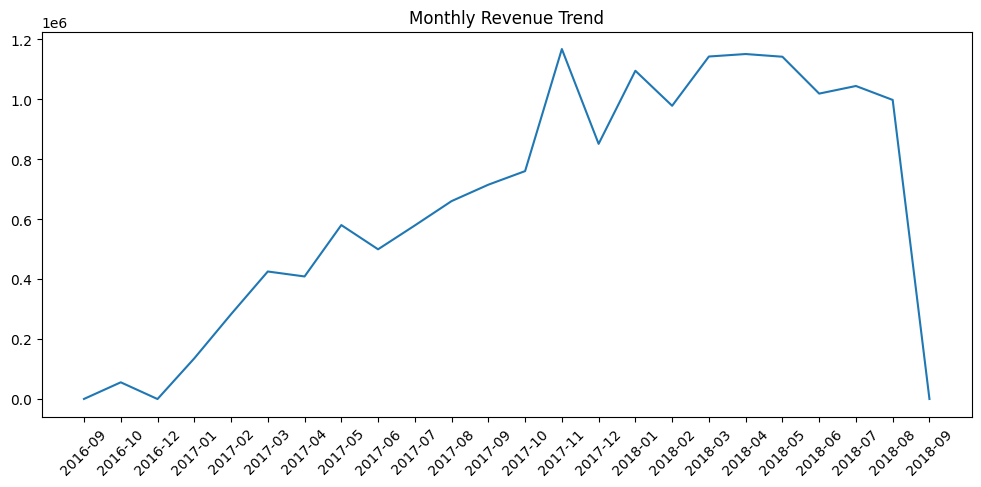

In [401]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue["order_month"].astype(str),
    monthly_revenue["revenue"]
)
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()

In [402]:
# Calculate monthly orders to analyze seasonality and trends in sales.
monthly_orders = (
    order_level_master.groupby(
        order_level_master["order_purchase_timestamp"].dt.to_period("M")
    )
    .size()
)
monthly_orders

order_purchase_timestamp
2016-09       3
2016-10     303
2016-12       1
2017-01     777
2017-02    1710
2017-03    2621
2017-04    2374
2017-05    3625
2017-06    3192
2017-07    3934
2017-08    4261
2017-09    4208
2017-10    4530
2017-11    7389
2017-12    5567
2018-01    7154
2018-02    6639
2018-03    7125
2018-04    6878
2018-05    6819
2018-06    6131
2018-07    6225
2018-08    6427
2018-09       1
Freq: M, dtype: int64

<Axes: xlabel='order_purchase_timestamp'>

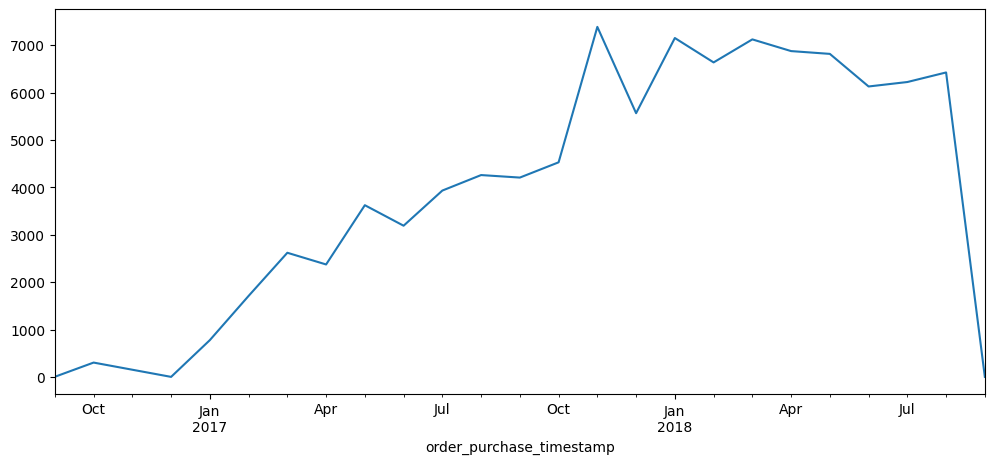

In [403]:
monthly_orders.plot(
    figsize=(12,5)
)

<Axes: xlabel='order_month'>

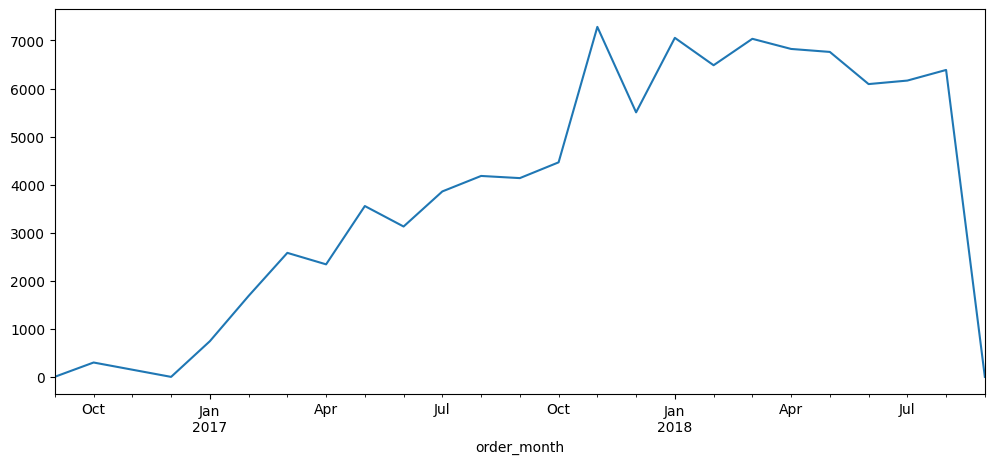

In [404]:
# Calculate monthly unique customers to analyze seasonality and trends in customer base.
monthly_customers = (
    order_level_master.groupby("order_month")
    ["customer_unique_id"]
    .nunique()
)

monthly_customers.plot(figsize=(12,5))

<Axes: ylabel='product_category_name'>

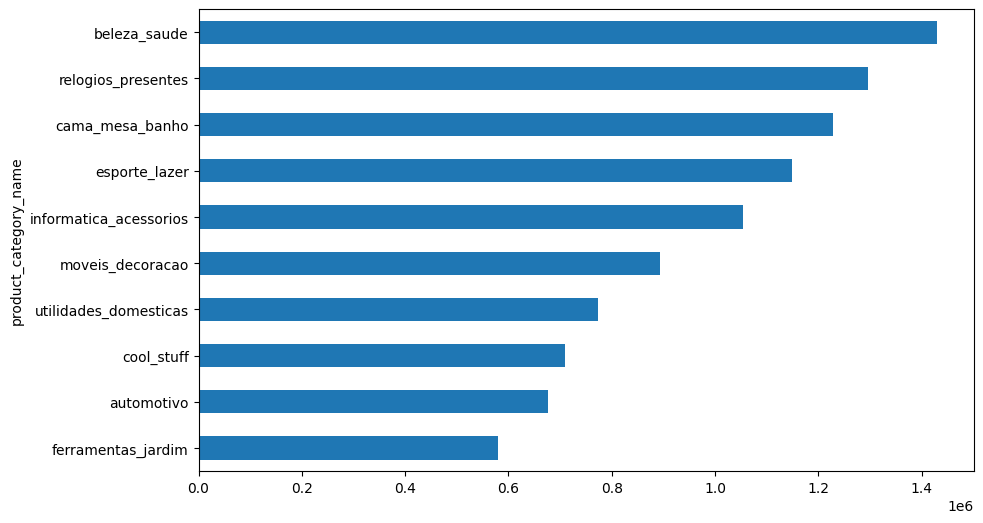

In [405]:
# Analyze top product categories by revenue to identify best-selling categories and focus areas for marketing and inventory management.
item_level_master["product_wise_revenue"] = (
    item_level_master["product_price"]
    + item_level_master["item_freight_value"]
)

top_categories = (
    item_level_master.groupby("product_category_name")["product_wise_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_categories.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

<Axes: ylabel='product_id'>

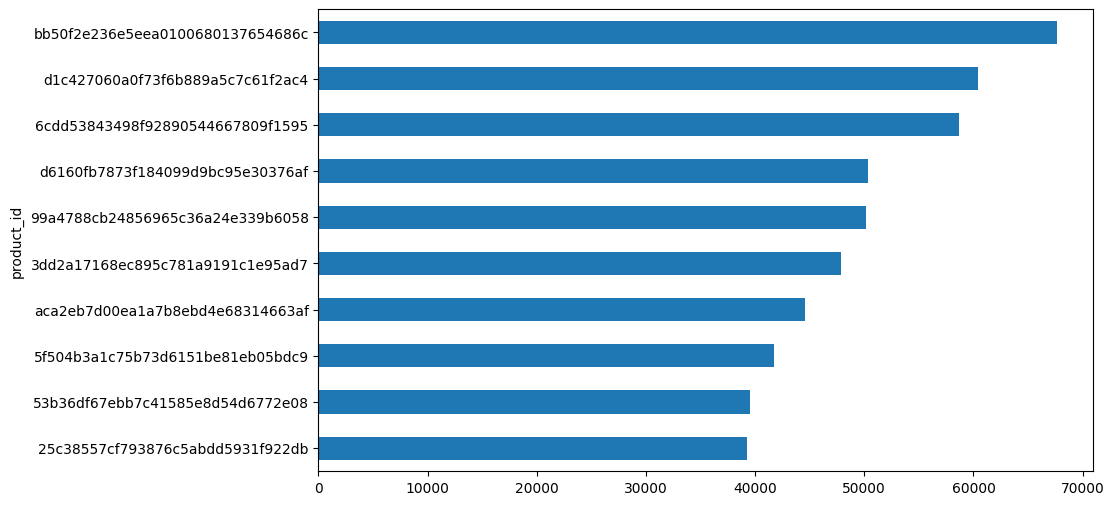

In [406]:
# Analyze top products by revenue to identify best-selling products and focus areas for marketing and inventory management.
top_products = (
    item_level_master.groupby("product_id")
    ["product_wise_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

<Axes: ylabel='seller_id'>

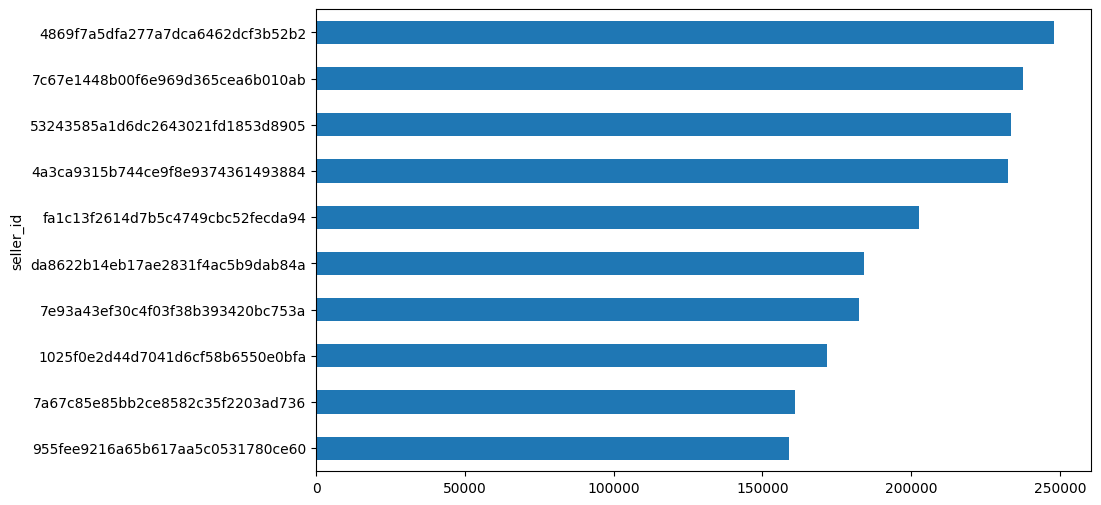

In [407]:
# Analyze revenue by customer state to identify key markets and regional performance differences.
top_sellers = (
    item_level_master.groupby("seller_id")
    ["product_wise_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sellers.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

<Axes: xlabel='customer_state'>

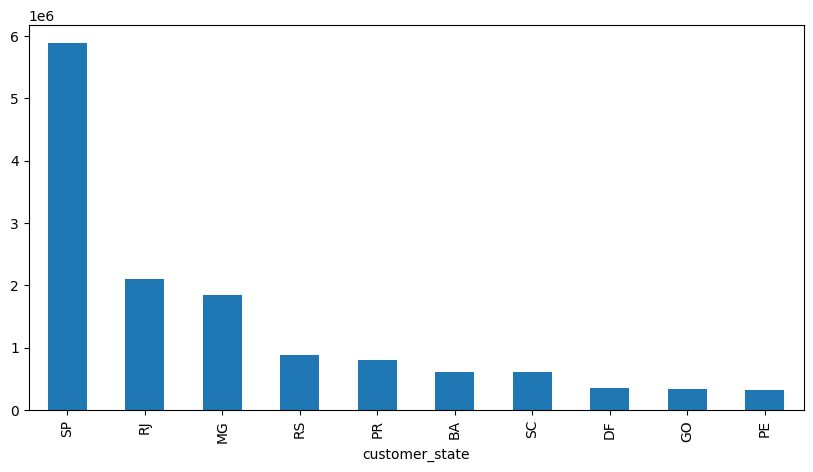

In [408]:
# Analyze revenue by customer state to identify key markets and regional performance differences.
state_revenue = (
    order_level_master.groupby("customer_state")
    ["revenue"]
    .sum()
    .sort_values(ascending=False)
)

state_revenue.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

<Axes: >

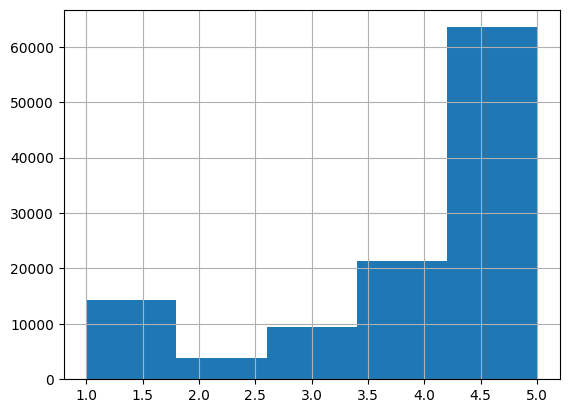

In [409]:
# As common Master has review level granularity, we can analyze the distribution of review scores to understand customer satisfaction levels and identify areas for improvement.
commonMaster["review_score"].value_counts().sort_index()
commonMaster["review_score"].hist(
    bins=5
)

<Axes: >

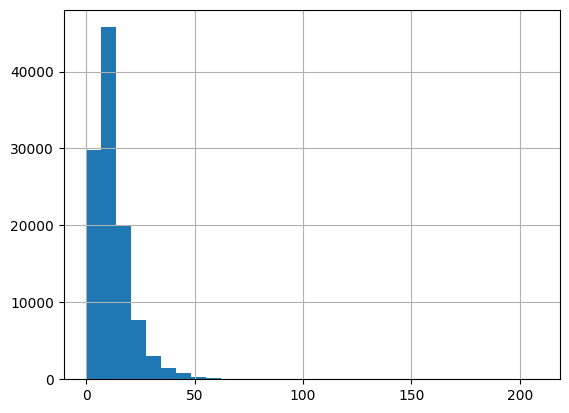

In [410]:
# Analyze delivery times to identify performance issues and their impact on customer satisfaction. As there are multiple order items per order, we will analyze delivery times at item level to get a more granular understanding of delivery performance.
item_level_master["delivery_time_days"].describe()
item_level_master["delivery_time_days"].hist(
    bins=30
)


<Axes: title={'center': 'delivery_time_days'}, xlabel='review_score'>

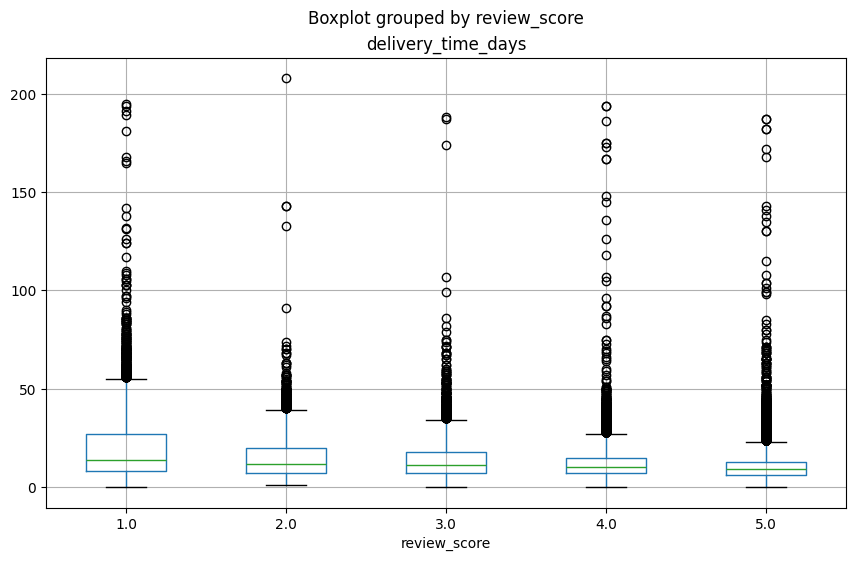

In [411]:
# Analyze the relationship between delivery times and review scores to understand how delivery performance impacts customer satisfaction and identify areas for improvement in logistics and delivery processes.
commonMaster.groupby("review_score")[
    "delivery_time_days"
].mean()

commonMaster.boxplot(
    column="delivery_time_days",
    by="review_score",
    figsize=(10,6)
)

In [412]:
# Calculate repeat purchase rate to understand customer loyalty and retention, which can inform strategies for improving customer engagement and lifetime value.
customer_orders = (
    order_level_master.groupby("customer_unique_id")
    ["order_id"]
    .nunique()
)

repeat_rate = (
    customer_orders > 1
).mean() * 100

repeat_rate

np.float64(3.028543068036621)

<Axes: >

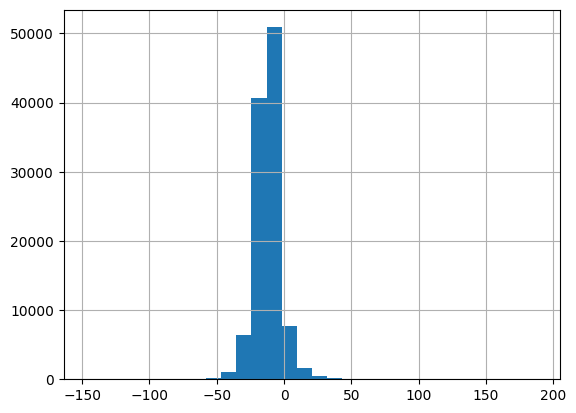

In [413]:
# Having an idea of delivery delay distribution can help us identify how many orders are delivered late and by how many days, which can inform strategies for improving delivery performance and customer satisfaction.
item_level_master["delivery_delay"].describe()
item_level_master["delivery_delay"].hist(
    bins=30
)

### Step 4: Summary
- Some basic plots were made(not all) and there distributions were understood after having the idea of final data we have

## Step 5: Statistical Analysis

Goal:
- Understand distributions
- Identify outliers
- Measure relationships between variables
- Validate findings from EDA

In [414]:
# Analyze revenue distribution to identify the presence of outliers and understand the overall sales performance, which can inform pricing strategies and promotional efforts.
order_level_master["revenue"].describe()

count    97894.000000
mean       160.339940
std        219.289148
min          9.590000
25%         61.852500
50%        105.280000
75%        176.740000
max      13664.080000
Name: revenue, dtype: float64

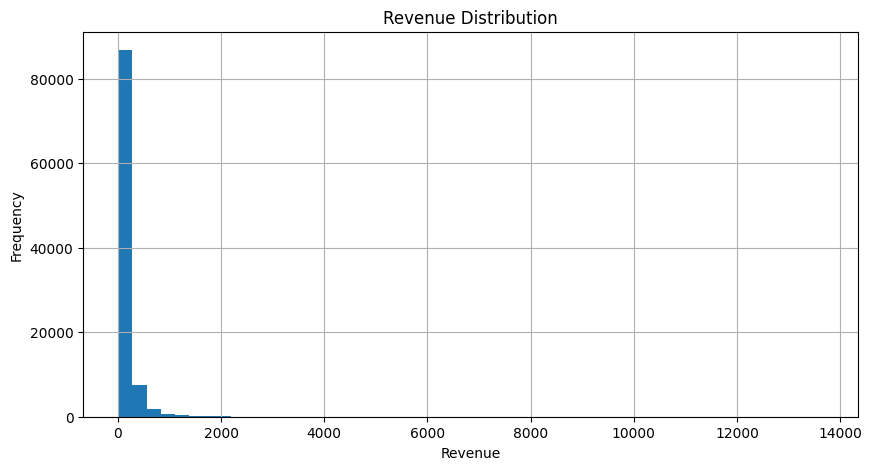

In [415]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
order_level_master["revenue"].hist(
    bins=50
)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

<Axes: >

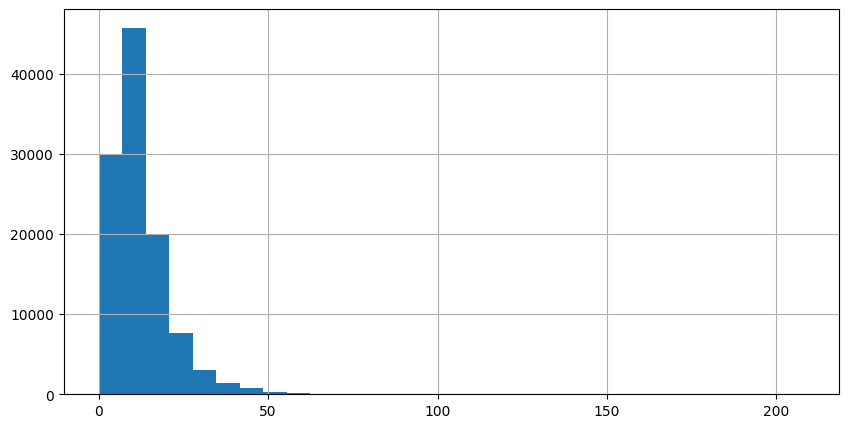

In [416]:
# Analyze delivery times to identify performance issues and their impact on customer satisfaction. As there are multiple order items per order, we will analyze delivery times at item level to get a more granular understanding of delivery performance.
item_level_master["delivery_time_days"].describe()
item_level_master["delivery_time_days"].hist(
    bins=30,
    figsize=(10,5)
)

<Axes: xlabel='review_score'>

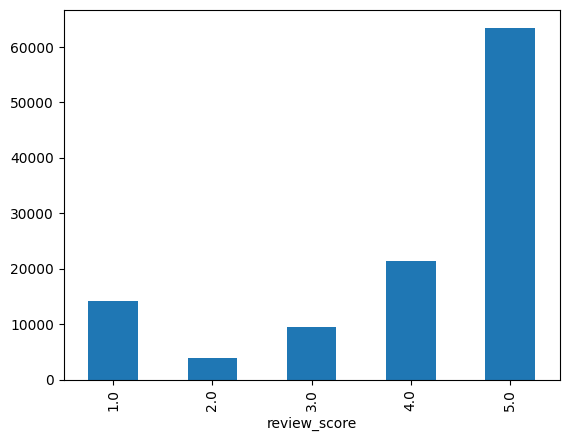

In [417]:
# Analyze the relationship between delivery times and review scores to understand how delivery performance impacts customer satisfaction and identify areas for improvement in logistics and delivery processes.
commonMaster["review_score"].value_counts().sort_index().plot(
    kind="bar"
)

<Axes: >

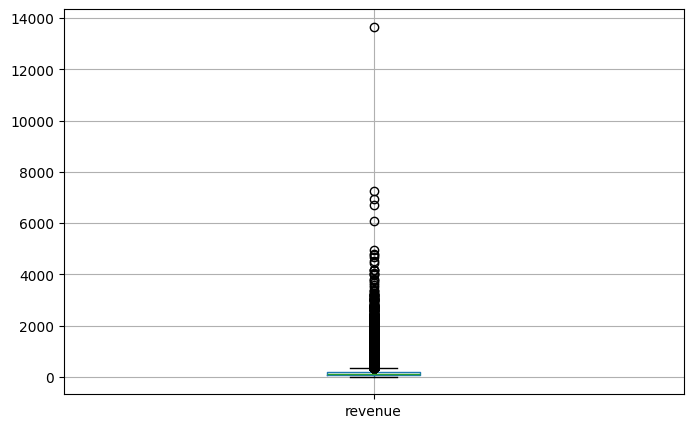

In [418]:
# Studying the revenue outliers by analyzing the distribution
order_level_master.boxplot(
    column="revenue",
    figsize=(8,5)
)

<Axes: >

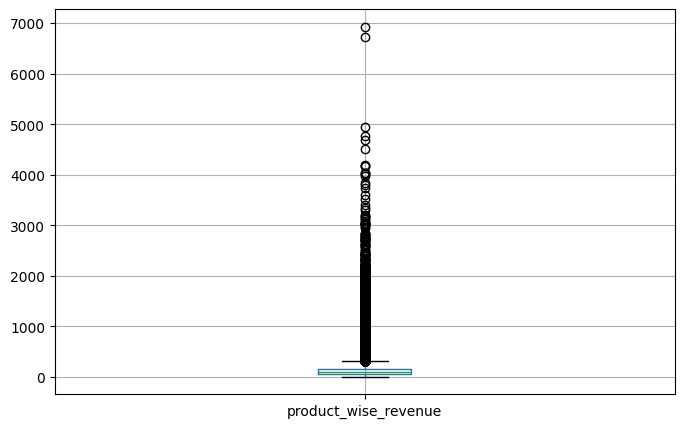

In [419]:
# Studying reason of revenue outliers by analyzing the distribution of product-wise revenue at item level to identify potential data issues or high-value transactions that may require special attention in analysis and decision-making.
item_level_master.boxplot(
    column="product_wise_revenue",
    figsize=(8,5)
)

In [420]:
# IQR method to identify outliers in revenue and remove them 
Q1 = order_level_master["revenue"].quantile(0.25)
Q3 = order_level_master["revenue"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

without_outliers = order_level_master[
    order_level_master["revenue"].between(lower, upper)
]

print(order_level_master.shape)
print(without_outliers.shape)

(97894, 38)
(90183, 38)


In [421]:
# Analyze delivery times to identify performance issues and their impact on customer satisfaction. As there are multiple order items per order, we will analyze delivery times at item level to get a more granular understanding of delivery performance.
item_level_master["delivery_time_days"].nlargest(10)

11911    208.0
29688    195.0
6696     194.0
17469    194.0
20685    194.0
31347    191.0
20768    189.0
19652    188.0
29397    187.0
29398    187.0
Name: delivery_time_days, dtype: float64

In [422]:
# Analyze the relationship between delivery times and review scores to understand how delivery performance impacts customer satisfaction and identify areas for improvement in logistics and delivery processes.
corr_df = order_level_master[
    [
        "revenue",
        "total_freight_value",
        "delivery_time_days",
        "avg_review_score"
    ]
]

corr_df.corr()

,revenue,total_freight_value,delivery_time_days,avg_review_score
revenue,1.000000,0.491804,0.069300,-0.046706
total_freight_value,0.491804,1.000000,0.167368,-0.088623
delivery_time_days,0.069300,0.167368,1.000000,-0.334220
avg_review_score,-0.046706,-0.088623,-0.334220,1.000000


In [423]:
# Analyze the relationship between delivery times and review scores to understand how delivery performance impacts customer satisfaction and identify areas for improvement in logistics and delivery processes.
item_level_master.groupby("avg_review_score")[
    "delivery_time_days"
].mean()

avg_review_score
1.000000    19.157527
1.500000    14.388889
2.000000    15.353649
2.500000    16.000000
3.000000    13.564130
3.333333    22.000000
3.500000    12.482759
4.000000    11.747991
4.333333     3.000000
4.500000    12.462687
5.000000    10.179413
Name: delivery_time_days, dtype: float64

<Axes: title={'center': 'delivery_time_days'}, xlabel='avg_review_score'>

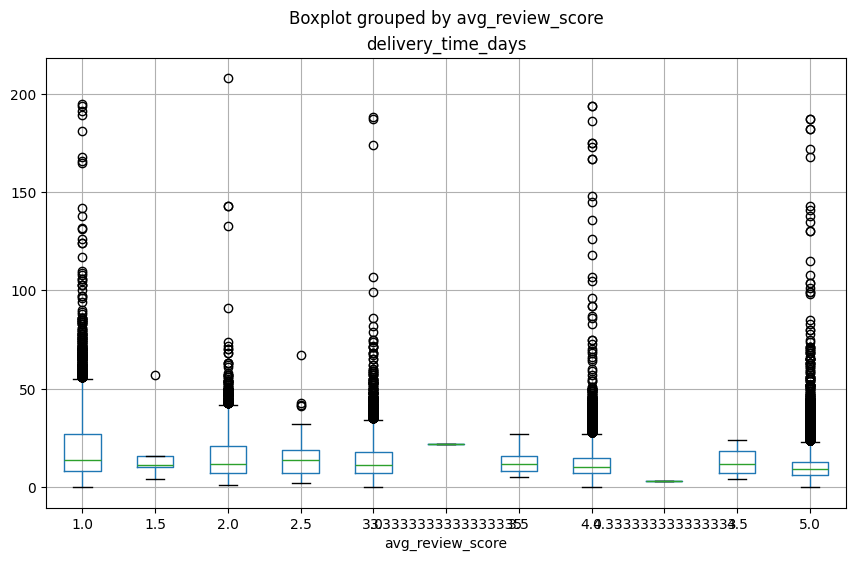

In [424]:
item_level_master.boxplot(
    column="delivery_time_days",
    by="avg_review_score",
    figsize=(10,6)
)

<Axes: >

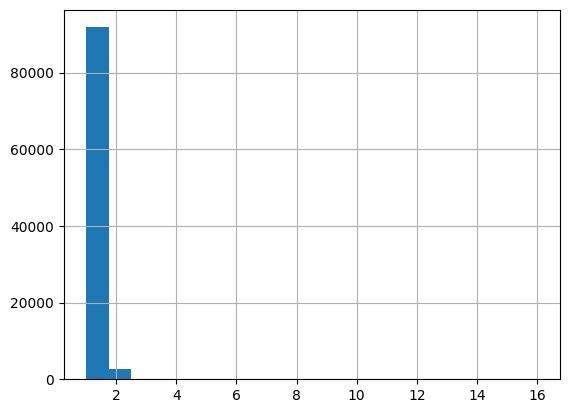

In [425]:
# Analyze repeat purchase behavior by calculating the distribution of number of orders per customer to understand customer loyalty and identify opportunities for improving retention strategies.
customer_orders = (
    order_level_master.groupby("customer_unique_id")
    ["order_id"]
    .nunique()
)

customer_orders.hist(
    bins=20
)

In [426]:
# Analyze seller revenue distribution to identify top-performing sellers and understand the competitive landscape, which can inform strategies for seller engagement and marketplace management.
seller_revenue = (
    item_level_master.groupby("seller_id")
    ["product_wise_revenue"]
    .sum()
    .sort_values(ascending=False)
)

top10_share = (
    seller_revenue.head(10).sum()
    /
    seller_revenue.sum()
) * 100

top10_share

np.float64(12.82794962416826)

## Conclusion

### Project Summary

This project analyzed the Brazilian E-Commerce Public Dataset by Olist to understand customer behavior, sales performance, product trends, and operational metrics.

The analysis involved:

- Understanding the relational structure of the dataset.
- Assessing data quality through missing value, duplicate, and consistency checks.
- Building clean analytical datasets at both order and item levels.
- Engineering business-relevant features such as revenue, delivery metrics, and product volume.
- Performing exploratory and statistical analysis to identify patterns, trends, distributions, correlations, and outliers.

---

### Key Findings

- Revenue distribution is highly right-skewed, with a small number of orders contributing disproportionately to total revenue.
- Customer purchasing behavior varies significantly across regions and product categories.
- Product and seller performance are unevenly distributed, indicating concentration among a subset of categories and sellers.
- Delivery performance shows variation across orders and may influence customer satisfaction.
- Several variables exhibit notable outliers, highlighting the importance of robust statistical analysis when interpreting business metrics.

---

### Business Insights

- High-value orders contribute significantly to overall revenue and should be monitored separately.
- Product categories and sellers that consistently generate higher revenue represent potential growth opportunities.
- Delivery-related metrics can be leveraged to improve customer experience and operational efficiency.
- Customer and geographic segmentation can support more targeted business strategies.

---

### Limitations

- The dataset does not contain information related to marketing campaigns, advertising spend, or profit margins.
- Customer Lifetime Value (CLV) and profitability metrics cannot be accurately calculated without additional business data.
- Findings are limited to the information available within the Olist dataset.

---

### Future Work

Possible extensions of this project include:

- Customer segmentation using clustering techniques.
- Sales forecasting and demand prediction.
- Customer churn and retention analysis.
- Recommendation system development.
- Natural Language Processing (NLP) on customer reviews.
- Machine learning models for review score prediction and delivery performance analysis.

---

### Final Remarks

This project demonstrates an end-to-end exploratory data analysis workflow, covering data understanding, cleaning, feature engineering, exploratory analysis, and statistical investigation. The resulting datasets and insights provide a strong foundation for advanced analytics and machine learning applications in the e-commerce domain.